# ============================================================
# INDIAN SIGN LANGUAGE (ISL) SENTENCE CLASSIFICATION
# COMPLETE TRAINING PIPELINE
# MediaPipe Tasks API Version
# PyTorch Edition — Optimized for NVIDIA GPU / Windows
# ============================================================

## Setup Instructions

### 1. Install PyTorch with CUDA support
Visit https://pytorch.org/get-started/locally/ and select your CUDA version.
Example for CUDA 12.1:
```
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
pip install mediapipe opencv-python scikit-learn tqdm matplotlib
```

### 2. Download MediaPipe model files and place in the same folder as this notebook:
- **hand_landmarker.task** → https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
- **pose_landmarker_full.task** → https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task

In [19]:
from pathlib import Path
import cv2
import numpy as np
import os
import pickle
print("basic ok")

basic ok


In [20]:
import mediapipe as mp
print("mediapipe ok")

mediapipe ok


In [21]:
import torch
import torch.nn as nn
print("torch ok")

torch ok


In [22]:
from sklearn.model_selection import train_test_split
print("sklearn ok")

sklearn ok


In [23]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm
import mediapipe as mp
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [24]:
# ============================================================
# GPU SETUP & VERIFICATION
# ============================================================

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✓ Found {torch.cuda.device_count()} GPU(s):")
    for i in range(torch.cuda.device_count()):
        print(f"   [{i}] {torch.cuda.get_device_name(i)}")
else:
    device = torch.device("cpu")
    print("⚠ No GPU detected — running on CPU.")
    print("  Make sure CUDA and cuDNN are installed and the correct torch+cu build is used.")

print(f"\nPyTorch version : {torch.__version__}")
print(f"Using device    : {device}")

✓ Found 1 GPU(s):
   [0] NVIDIA GeForce RTX 3050 4GB Laptop GPU

PyTorch version : 2.5.1+cu121
Using device    : cuda


In [25]:
# ============================================================
# DATASET PATH
# ============================================================

DATA_DIR = Path(
    "isl_nmf/data/isl_csltr/ISL_CSLRT_Corpus/ISL_CSLRT_Corpus/Videos_Sentence_Level"
)

# ============================================================
# CONFIG
# ============================================================

SEQ_LEN = 30

# pose (33*3) + left hand (21*3) + right hand (21*3)
NUM_KEYPOINTS = 225

FRAME_SKIP = 5

# Increase batch size for GPU — 8 is too small and wastes GPU throughput
BATCH_SIZE = 32

HAND_MODEL = "hand_landmarker.task"
POSE_MODEL = "pose_landmarker_full.task"

In [26]:
# ============================================================
# MEDIAPIPE TASKS API
# ============================================================

# NOTE: MediaPipe runs on CPU only (it does not use your NVIDIA GPU).
# This is fine — keypoint extraction is a preprocessing step.
# Results are cached to disk so you only do it once.

BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions

hand_options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=HAND_MODEL),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=2
)

pose_options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=POSE_MODEL),
    running_mode=VisionRunningMode.IMAGE
)

hand_detector = HandLandmarker.create_from_options(hand_options)
pose_detector = PoseLandmarker.create_from_options(pose_options)

print("✓ MediaPipe Tasks models loaded")

✓ MediaPipe Tasks models loaded


In [27]:
# ============================================================
# LOAD CLASS NAMES
# ============================================================

class_names = sorted([
    d.name
    for d in DATA_DIR.iterdir()
    if d.is_dir()
])

print(f"Total Classes: {len(class_names)}")
print(class_names[:10])

Total Classes: 101
['He is going into the room', 'No need to worry dont worry', 'This place is beautiful', 'are you free today', 'are you hiding something', 'bring water for me', 'can i help you', 'can you repeat that please', 'comb your hair', 'congratulations']


In [28]:
# ============================================================
# EXTRACT KEYPOINTS FROM A SINGLE FRAME
# ============================================================

def extract_keypoints(frame):

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # ---- POSE ----
    pose_result = pose_detector.detect(mp_image)
    pose = np.zeros(33 * 3)

    if pose_result.pose_landmarks:
        pose_landmarks = pose_result.pose_landmarks[0]
        pose = np.array([
            [lm.x, lm.y, lm.z]
            for lm in pose_landmarks
        ]).flatten()

    # ---- HANDS ----
    hand_result = hand_detector.detect(mp_image)
    left_hand  = np.zeros(21 * 3)
    right_hand = np.zeros(21 * 3)

    if hand_result.hand_landmarks:
        for idx, hand_landmarks in enumerate(hand_result.hand_landmarks):

            handedness = (
                hand_result.handedness[idx][0].category_name
            )

            hand_array = np.array([
                [lm.x, lm.y, lm.z]
                for lm in hand_landmarks
            ]).flatten()

            if handedness == "Left":
                left_hand = hand_array
            else:
                right_hand = hand_array

    # ---- CONCATENATE ----
    keypoints = np.concatenate([pose, left_hand, right_hand])

    return keypoints


# ============================================================
# LOAD ONE VIDEO → FIXED-LENGTH SEQUENCE
# ============================================================

def load_video(video_path):

    cap = cv2.VideoCapture(str(video_path))

    frames = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1

        if frame_idx % FRAME_SKIP != 0:
            continue

        keypoints = extract_keypoints(frame)
        frames.append(keypoints)

    cap.release()

    if len(frames) == 0:
        return None

    frames = np.array(frames)

    # ---- FIX SEQUENCE LENGTH ----

    if len(frames) > SEQ_LEN:
        # Uniformly sample SEQ_LEN frames
        idx = np.linspace(0, len(frames) - 1, SEQ_LEN).astype(int)
        frames = frames[idx]

    elif len(frames) < SEQ_LEN:
        # Pad at end with zeros
        padding = np.zeros((SEQ_LEN - len(frames), NUM_KEYPOINTS))
        frames = np.concatenate([frames, padding])

    return frames.astype(np.float32)  # cast to float32 early to save RAM

In [29]:
# ============================================================
# BUILD DATASET (with caching)
# ============================================================

X = []
y = []

# Handle .avi and .mov which are common in sign language datasets
video_extensions = [".mp4", ".MP4", ".avi", ".AVI", ".mov", ".MOV"]

cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

for class_name in class_names:

    class_dir = DATA_DIR / class_name

    video_files = []
    for ext in video_extensions:
        video_files.extend(class_dir.glob(f"*{ext}"))

    print(f"\n{class_name}: {len(video_files)} videos")

    for video_path in tqdm(video_files):

        try:
            safe_name = (
                class_name.replace(" ", "_")
                + "_"
                + video_path.stem.replace(" ", "_")
            )
            cache_path = cache_dir / f"{safe_name}.npy"

            if cache_path.exists():
                sequence = np.load(cache_path)
            else:
                sequence = load_video(video_path)
                if sequence is not None:
                    np.save(cache_path, sequence)

            if sequence is not None:
                X.append(sequence)
                y.append(class_name)

        except Exception as e:
            print(f"\nError processing: {video_path}")
            print(e)

print("\n✓ Feature extraction completed")

# ============================================================
# CONVERT TO NUMPY
# ============================================================

X = np.array(X, dtype=np.float32)  # explicit dtype
y = np.array(y)

print("\nDataset Shape:")
print(X.shape)
print(y.shape)


He is going into the room: 14 videos


100%|██████████| 14/14 [00:00<00:00, 2055.46it/s]



No need to worry dont worry: 2 videos


100%|██████████| 2/2 [00:00<00:00, 1340.68it/s]



This place is beautiful: 14 videos


...


you do anything, i do not care: 12 videos


100%|██████████| 12/12 [00:00<?, ?it/s]



you need a medicine, take this one: 14 videos


100%|██████████| 14/14 [00:00<00:00, 6585.20it/s]


✓ Feature extraction completed

Dataset Shape:
(1374, 30, 225)
(1374,)


## ⚠️ Class Imbalance Check
Some classes may have very few samples (e.g., 2 videos). 
Run this cell to inspect and optionally remove thin classes before training.

In [30]:
# ============================================================
# CLASS IMBALANCE AUDIT — remove or flag thin classes
# ============================================================

import collections

class_counts = collections.Counter(y)  # y is raw string labels
thin_classes = {cls: cnt for cls, cnt in class_counts.items() if cnt < 5}

print(f"Total samples  : {len(y)}")
print(f"Total classes  : {len(class_counts)}")
print(f"Classes with < 5 samples (will likely have 0 test samples with 80/20 split):")
for cls, cnt in sorted(thin_classes.items(), key=lambda x: x[1]):
    print(f"  {cnt:3d} samples — {cls}")

# --- Option A: Remove thin classes entirely (recommended if accuracy matters) ---
MIN_SAMPLES = 5   # <-- adjust threshold as needed

mask = np.array([class_counts[label] >= MIN_SAMPLES for label in y])
X_filtered = X[mask]
y_filtered = y[mask]

removed = len(y) - len(y_filtered)
print(f"Removed {removed} samples from {len(thin_classes)} thin classes.")
print(f"Remaining: {len(y_filtered)} samples across {len(set(y_filtered))} classes")

# Overwrite X and y with filtered versions for the rest of the pipeline
# Comment these two lines out if you want to KEEP all classes.
X = X_filtered
y = y_filtered
print("✓ X and y updated with filtered data (thin classes removed)")
print("  If you want to keep all classes, comment out the last two assignments above.")

Total samples  : 1374
Total classes  : 101
Classes with < 5 samples (will likely have 0 test samples with 80/20 split):
    2 samples — No need to worry dont worry
    2 samples — i dont agree
Removed 4 samples from 2 thin classes.
Remaining: 1370 samples across 99 classes
✓ X and y updated with filtered data (thin classes removed)
  If you want to keep all classes, comment out the last two assignments above.


In [31]:
# ============================================================
# ENCODE LABELS
# ============================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Save the encoder so you can decode predictions later
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)
print("✓ Label encoder saved as label_encoder.pkl")

# ============================================================
# TRAIN / TEST SPLIT
# Use stratify to ensure all classes appear in both splits
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_encoded   # critical for small datasets
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ============================================================
# CONVERT TO PYTORCH TENSORS & BUILD DATALOADERS
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("\n✓ DataLoaders ready")
print(f"  Train batches : {len(train_loader)}")
print(f"  Test  batches : {len(test_loader)}")

✓ Label encoder saved as label_encoder.pkl

Train Shape: (1096, 30, 225)
Test Shape : (274, 30, 225)

✓ DataLoaders ready
  Train batches : 35
  Test  batches : 9


In [32]:
# ============================================================
# BUILD MODEL
# TCN (Temporal Convolutional Network) replacing BiLSTM
# Architecture: Stacked TCN residual blocks → GlobalAvgPool → Dense(256) → Dense(128) → Softmax
# ============================================================

class TemporalBlock(nn.Module):
    """
    One TCN residual block:
      - Two causal dilated Conv1d layers with the same dilation
      - Weight norm for training stability
      - ReLU + Dropout after each conv
      - 1x1 residual projection when in/out channels differ
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation   # causal padding

        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation)
        )
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation)
        )
        self.relu1    = nn.ReLU()
        self.relu2    = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        # Residual projection (1x1 conv) if channel dims differ
        self.downsample = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels else None
        )
        self.relu_out = nn.ReLU()

    def forward(self, x):
        # x: (batch, channels, seq_len)
        out = self.conv1(x)
        out = out[:, :, :x.size(2)]   # trim causal padding
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = out[:, :, :x.size(2)]   # trim causal padding
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu_out(out + res)


class ISLModel(nn.Module):
    """
    TCN for ISL sentence-level classification.

    Stack of TemporalBlocks with exponentially increasing dilation
    (1, 2, 4, 8) gives a receptive field that easily covers SEQ_LEN=30.
    Global average pooling collapses the time axis before the classifier.
    """
    def __init__(
        self,
        input_size,
        num_classes,
        num_channels=None,   # list of out_channels per TCN block
        kernel_size=3,
        dropout=0.2,
        fc_dropout1=0.4,
        fc_dropout2=0.3,
    ):
        super().__init__()

        if num_channels is None:
            num_channels = [128, 128, 256, 256]   # 4 blocks

        # Build TCN blocks
        layers = []
        in_ch = input_size
        for i, out_ch in enumerate(num_channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout)
            )
            in_ch = out_ch

        self.tcn = nn.Sequential(*layers)

        # Global average pool over time → (batch, out_ch)
        self.gap = nn.AdaptiveAvgPool1d(1)

        # Classifier head
        self.bn       = nn.BatchNorm1d(in_ch)
        self.fc1      = nn.Linear(in_ch, 256)
        self.relu1    = nn.ReLU()
        self.drop1    = nn.Dropout(fc_dropout1)
        self.fc2      = nn.Linear(256, 128)
        self.relu2    = nn.ReLU()
        self.drop2    = nn.Dropout(fc_dropout2)
        self.out      = nn.Linear(128, num_classes)
        # CrossEntropyLoss includes Softmax internally

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = x.permute(0, 2, 1)         # → (batch, input_size, seq_len) for Conv1d
        x = self.tcn(x)                # → (batch, out_ch, seq_len)
        x = self.gap(x).squeeze(-1)    # → (batch, out_ch)
        x = self.bn(x)
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        return self.out(x)


model = ISLModel(
    input_size=NUM_KEYPOINTS,
    num_classes=len(class_names),
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")


ISLModel(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(225, 128, kernel_size=(3,), stride=(1,), padding=(2,))
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu1): ReLU()
      (relu2): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(225, 128, kernel_size=(1,), stride=(1,))
      (relu_out): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu1): ReLU()
      (relu2): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
      (relu_out): ReLU()
    )
    (2): TemporalBlock(
      (conv1): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
      (conv2): Conv1d(256, 256, kernel_size=(3,), stride=

C:\Users\Sh.Pritpal Singh\Desktop\School Work\extra_gitstuff\SpellChecker\torch_gpu\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [33]:
# ============================================================
# COMPILE MODEL  (loss + optimizer)
# ============================================================

criterion = nn.CrossEntropyLoss()          # equivalent to categorical_crossentropy + softmax
optimizer = optim.Adam(model.parameters(), lr=1e-3)   # start at 1e-3, let ReduceLR handle decay

# ReduceLROnPlateau — mirrors Keras callback
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

print("✓ Loss, optimizer, and scheduler configured")

✓ Loss, optimizer, and scheduler configured


In [34]:
# ============================================================
# TRAINING LOOP
# Mirrors Keras model.fit() with EarlyStopping + ModelCheckpoint + ReduceLROnPlateau
# ============================================================

EPOCHS       = 200
PATIENCE     = 15   # EarlyStopping patience (was 10, bumped for 101-class task)
BEST_CKPT    = "isl_best_model.pt"

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc   = 0.0
patience_count = 0


def run_epoch(loader, training=True):
    """One forward pass over a DataLoader. Returns (avg_loss, accuracy)."""
    if training:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss   = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == yb).sum().item()
            total      += xb.size(0)

    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(test_loader,  training=False)

    # Step scheduler on val_loss (mirrors Keras ReduceLROnPlateau)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:3d}/{EPOCHS}  "
        f"loss={train_loss:.4f}  acc={train_acc:.4f}  "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    # ModelCheckpoint — save best val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_CKPT)
        print(f"  ✓ Best checkpoint saved  (val_acc={best_val_acc:.4f})")
        patience_count = 0
    else:
        patience_count += 1

    # EarlyStopping
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs.")
        break

# Restore best weights (mirrors restore_best_weights=True)
model.load_state_dict(torch.load(BEST_CKPT, weights_only=True))
print("\n✓ Training complete — best weights restored")

Epoch   1/200  loss=4.6099  acc=0.0109  val_loss=4.5213  val_acc=0.0146  lr=1.00e-03
  ✓ Best checkpoint saved  (val_acc=0.0146)
Epoch   2/200  loss=4.4585  acc=0.0164  val_loss=4.4854  val_acc=0.0328  lr=1.00e-03
  ✓ Best checkpoint saved  (val_acc=0.0328)
Epoch   3/200  loss=4.3517  acc=0.0210  val_loss=4.3811  val_acc=0.0146  lr=1.00e-03
Epoch   4/200  loss=4.2406  acc=0.0328  val_loss=4.2006  val_acc=0.0584  lr=1.00e-03
  ✓ Best checkpoint saved  (val_acc=0.0584)
Epoch   5/200  loss=4.1086  acc=0.0338  val_loss=4.0972  val_acc=0.0438  lr=1.00e-03
Epoch   6/200  loss=3.9686  acc=0.0602  val_loss=3.8780  val_acc=0.0547  lr=1.00e-03
Epoch   7/200  loss=3.8589  acc=0.0630  val_loss=4.1362  val_acc=0.0547  lr=1.00e-03
Epoch   8/200  loss=3.7329  acc=0.0849  val_loss=3.7857  val_acc=0.0803  lr=1.00e-03
  ✓ Best checkpoint saved  (val_acc=0.0803)
Epoch   9/200  loss=3.6048  acc=0.0776  val_loss=3.6237  val_acc=0.0657  lr=1.00e-03
Epoch  10/200  loss=3.5304  acc=0.0776  val_loss=3.9677  va

In [35]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

torch.save(model.state_dict(), "isl_sentence_model.pt")
print("✓ Model saved as isl_sentence_model.pt")
print("  (Best checkpoint also saved as isl_best_model.pt)")

# ============================================================
# EVALUATE
# ============================================================

_, test_acc = run_epoch(test_loader, training=False)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

✓ Model saved as isl_sentence_model.pt
  (Best checkpoint also saved as isl_best_model.pt)

Test Accuracy: 85.40%


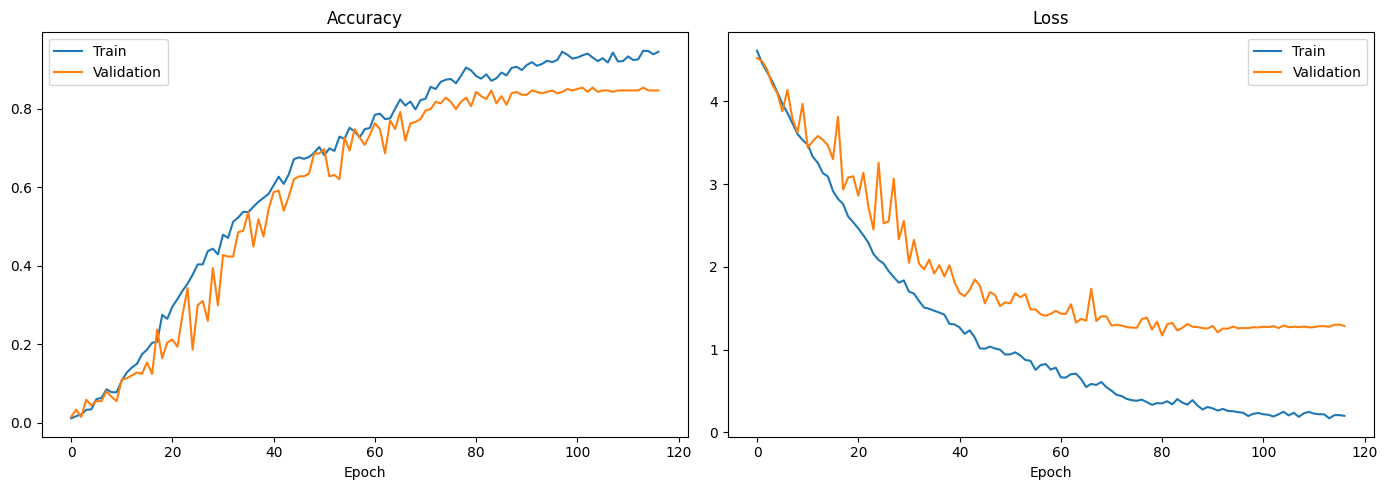

✓ Training plot saved as training_history.png


In [36]:
# ============================================================
# PLOT TRAINING HISTORY
# ============================================================

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_acc'], label='Train')
ax1.plot(history['val_acc'],   label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_loss'], label='Train')
ax2.plot(history['val_loss'],   label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("✓ Training plot saved as training_history.png")